# 02 Behavior Policy And Propensity Diagnostics

This notebook is the bridge between basic EDA and actual off-policy estimators.

Notebook 1 showed that Open Bandit has the core ingredients for off-policy evaluation: logged actions, observed rewards, context features, and behavior-policy propensities. Notebook 2 asks a more focused question:

> Can we trust the logging-policy information enough to use it in IPS, self-normalized IPS, and doubly robust OPE?

That means we will study the behavior policy itself. We will look at action support, position support, propensity score distributions, inverse-propensity weight risk, and a preview comparison between the `random/men` and `bts/men` behavior policies.

This notebook still does not try to make a final product claim about a new recommendation policy. Its job is diagnostic: understand where OPE will be stable, where it may be noisy, and why the `random/men` campaign is the safest starting point.


## OPE Recap: Why Propensities Matter

In off-policy evaluation, we use data generated by one policy to estimate the value of another policy.

- The **behavior policy** or **logging policy** generated the historical data.
- The **evaluation policy** is the new policy we want to evaluate offline.
- The **action** is the item shown to the user.
- The **reward** is the observed click.
- The **propensity score** is the probability that the behavior policy assigned to the logged action.

The key reweighting idea is:

`weight = evaluation_policy_probability / behavior_policy_probability`

If the evaluation policy would have chosen the logged item more often than the behavior policy did, that row receives a larger weight. If the evaluation policy would rarely choose it, that row receives a smaller weight.

This creates two practical requirements. First, the behavior propensity must be positive whenever the evaluation policy might choose that action. Second, very small behavior propensities create large weights, which can make estimates unstable. This notebook focuses on those two issues.


## Notebook Setup

This cell imports the libraries used for diagnostics. We use `zipfile` to read the BTS comparison sample directly from the Open Bandit archive, while the random-policy sample comes from the parquet cache written by Notebook 1.

The plotting settings match the rest of the project so the notebook reads like one coherent portfolio artifact.


In [1]:
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.6f}".format)

sns.set_theme(style="whitegrid", context="notebook")


This cell prepares the notebook environment for behavior-policy propensities and support diagnostics. There is no estimator output yet; the main value is that the imports, display settings, and plotting defaults are ready for the OPE diagnostics that follow.


## Locate Project Files

This cell finds the repository root by walking upward until it sees the Open Bandit zip. It then defines the paths used in this notebook.

The random-policy sample is loaded from `data/processed/open_bandit_random_men_sample.parquet`, which was created by Notebook 1. The BTS sample will be read from the raw zip and cached to `data/processed/open_bandit_bts_men_sample.parquet` for later notebooks.


In [2]:
OPEN_BANDIT_ZIP_RELATIVE_PATH = Path("data/open_bandit/open_bandit_dataset.zip")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / OPEN_BANDIT_ZIP_RELATIVE_PATH).exists()
)

OPEN_BANDIT_ZIP = PROJECT_ROOT / OPEN_BANDIT_ZIP_RELATIVE_PATH
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
RANDOM_SAMPLE_PATH = PROCESSED_DIR / "open_bandit_random_men_sample.parquet"
BTS_SAMPLE_PATH = PROCESSED_DIR / "open_bandit_bts_men_sample.parquet"

pd.DataFrame(
    {
        "path_name": ["project_root", "open_bandit_zip", "random_sample", "bts_sample_cache"],
        "path": [PROJECT_ROOT, OPEN_BANDIT_ZIP, RANDOM_SAMPLE_PATH, BTS_SAMPLE_PATH],
        "exists": [PROJECT_ROOT.exists(), OPEN_BANDIT_ZIP.exists(), RANDOM_SAMPLE_PATH.exists(), BTS_SAMPLE_PATH.exists()],
    }
)


,path_name,path,exists
0,project_root,/home/apex/Documents/ranking_sys,True
1,open_bandit_zip,/home/apex/Documents/ranking_sys/data/open_ban...,True
2,random_sample,/home/apex/Documents/ranking_sys/data/processe...,True
3,bts_sample_cache,/home/apex/Documents/ranking_sys/data/processe...,True


The printed paths are a reproducibility checkpoint. Once the notebook can find the cached data and writeup folders, the rest of the analysis can run without manual path edits.


## Load The Random-Policy Sample

This cell loads the cached `random/men` sample from Notebook 1. The random campaign is our clean starting point because the behavior policy explores the action space broadly and assigns nearly uniform propensities.

We add a `behavior_policy` label so that tables and plots can compare random logging with BTS logging later in the notebook.


In [3]:
if not RANDOM_SAMPLE_PATH.exists():
    raise FileNotFoundError(
        f"Missing {RANDOM_SAMPLE_PATH}. Run 01_open_bandit_eda.ipynb first to create the cached sample."
    )

random_df = pd.read_parquet(RANDOM_SAMPLE_PATH).assign(behavior_policy="random")

random_df.head()


,timestamp,item_id,position,click,propensity_score,user_feature_0,user_feature_1,user_feature_2,user_feature_3,user-item_affinity_0,user-item_affinity_1,user-item_affinity_2,user-item_affinity_3,user-item_affinity_4,user-item_affinity_5,user-item_affinity_6,user-item_affinity_7,user-item_affinity_8,user-item_affinity_9,user-item_affinity_10,user-item_affinity_11,user-item_affinity_12,user-item_affinity_13,user-item_affinity_14,user-item_affinity_15,user-item_affinity_16,user-item_affinity_17,user-item_affinity_18,user-item_affinity_19,user-item_affinity_20,user-item_affinity_21,user-item_affinity_22,user-item_affinity_23,user-item_affinity_24,user-item_affinity_25,user-item_affinity_26,user-item_affinity_27,user-item_affinity_28,user-item_affinity_29,user-item_affinity_30,user-item_affinity_31,user-item_affinity_32,user-item_affinity_33,date,hour,inverse_behavior_propensity,item_feature_0,item_feature_1,item_feature_2,item_feature_3,behavior_policy
0,2019-11-24 00:00:03.800821+00:00,0,1,0,0.029412,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-11-24,0,34.000000,-0.677183,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,random
1,2019-11-24 00:00:03.801019+00:00,25,3,0,0.029412,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-11-24,0,34.000000,-0.461600,9874ffb54e9b0a269e29bbb2f5328735,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,random
2,2019-11-24 00:00:03.801099+00:00,23,2,0,0.029412,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-11-24,0,34.000000,-0.569392,55fe518d85813954c7d9b8a875ff2453,cc75031396a5aa830885915aa93f49d0,b61cfaadd526b816e3aeb9b7be4b4759,random
3,2019-11-24 00:00:17.634355+00:00,25,1,0,0.029412,1a2b2ad3a7f218a0d709dd9c656fda27,e3528f5280f04c0031d337da1def86ea,398773dacf8501ee8f76e3706ccafbba,47e7dd7d9ccbe31d57ce716dba831d44,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-11-24,0,34.000000,-0.461600,9874ffb54e9b0a269e29bbb2f5328735,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,random
4,2019-11-24 00:00:17.634998+00:00,30,2,0,0.029412,1a2b2ad3a7f218a0d709dd9c656fda27,e3528f5280f04c0031d337da1def86ea,398773dacf8501ee8f76e3706ccafbba,47e7dd7d9ccbe31d57ce716dba831d44,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-11-24,0,34.000000,-0.914324,61c5

The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


## Load A BTS Comparison Sample

Open Bandit also includes logs from a Bernoulli Thompson Sampling policy, abbreviated as `bts`. BTS is adaptive: it uses prior feedback to put more probability on items it currently believes are promising.

This cell reads the first `SAMPLE_ROWS` from `bts/men/men.csv`. We parse timestamps using `format="mixed"` because Open Bandit contains both fractional-second and whole-second timestamp strings. We also compute `inverse_behavior_propensity`, which is the raw `1 / propensity_score` diagnostic used later.


In [4]:
SAMPLE_ROWS = len(random_df)
BTS_LOG_MEMBER = "open_bandit_dataset/bts/men/men.csv"

with ZipFile(OPEN_BANDIT_ZIP) as zf:
    with zf.open(BTS_LOG_MEMBER) as f:
        bts_df = pd.read_csv(f, nrows=SAMPLE_ROWS, index_col=0)

bts_df = bts_df.assign(
    timestamp=pd.to_datetime(bts_df["timestamp"], utc=True, format="mixed"),
    behavior_policy="bts",
)
bts_df = bts_df.assign(
    date=bts_df["timestamp"].dt.date,
    hour=bts_df["timestamp"].dt.hour,
    inverse_behavior_propensity=1 / bts_df["propensity_score"],
)

bts_df.head()


,timestamp,item_id,position,click,propensity_score,user_feature_0,user_feature_1,user_feature_2,user_feature_3,user-item_affinity_0,user-item_affinity_1,user-item_affinity_2,user-item_affinity_3,user-item_affinity_4,user-item_affinity_5,user-item_affinity_6,user-item_affinity_7,user-item_affinity_8,user-item_affinity_9,user-item_affinity_10,user-item_affinity_11,user-item_affinity_12,user-item_affinity_13,user-item_affinity_14,user-item_affinity_15,user-item_affinity_16,user-item_affinity_17,user-item_affinity_18,user-item_affinity_19,user-item_affinity_20,user-item_affinity_21,user-item_affinity_22,user-item_affinity_23,user-item_affinity_24,user-item_affinity_25,user-item_affinity_26,user-item_affinity_27,user-item_affinity_28,user-item_affinity_29,user-item_affinity_30,user-item_affinity_31,user-item_affinity_32,user-item_affinity_33,behavior_policy,date,hour,inverse_behavior_propensity
0,2019-11-24 00:00:00.020518+00:00,10,1,0,0.019455,81ce123cbb5bd8ce818f60fb3586bba5,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,bts,2019-11-24,0,51.400668
1,2019-11-24 00:00:00.025815+00:00,13,2,0,0.329710,81ce123cbb5bd8ce818f60fb3586bba5,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,bts,2019-11-24,0,3.032968
2,2019-11-24 00:00:00.026514+00:00,0,3,0,0.044465,81ce123cbb5bd8ce818f60fb3586bba5,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,bts,2019-11-24,0,22.489599
3,2019-11-24 00:00:00.972404+00:00,13,2,0,0.329710,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,bts,2019-11-24,0,3.032968
4,2019-11-24 00:00:00.972817+00:00,6,3,0,0.051515,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,bts,2019-11-24,0,19.411822


The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


## Align The Comparison Columns

The random sample includes item features joined in Notebook 1, while the BTS sample currently contains only the raw logged fields. For policy-behavior diagnostics, we only need fields that exist in both tables.

This cell creates a combined comparison table with shared columns. It keeps the diagnostics focused on logging behavior: actions, positions, rewards, propensities, and timestamps.


In [5]:
comparison_cols = [
    "behavior_policy",
    "timestamp",
    "date",
    "hour",
    "item_id",
    "position",
    "click",
    "propensity_score",
    "inverse_behavior_propensity",
]

comparison_df = pd.concat(
    [random_df[comparison_cols], bts_df[comparison_cols]],
    ignore_index=True,
)

comparison_df.head()


,behavior_policy,timestamp,date,hour,item_id,position,click,propensity_score,inverse_behavior_propensity
0,random,2019-11-24 00:00:03.800821+00:00,2019-11-24,0,0,1,0,0.029412,34.000000
1,random,2019-11-24 00:00:03.801019+00:00,2019-11-24,0,25,3,0,0.029412,34.000000
2,random,2019-11-24 00:00:03.801099+00:00,2019-11-24,0,23,2,0,0.029412,34.000000
3,random,2019-11-24 00:00:17.634355+00:00,2019-11-24,0,25,1,0,0.029412,34.000000
4,random,2019-11-24 00:00:17.634998+00:00,2019-11-24,0,30,2,0,0.029412,34.000000


Aligning columns makes the random and BTS logs comparable. With a common schema, the next diagnostics can focus on policy differences instead of table-format differences.


## Basic Policy-Level Summary

This cell summarizes each behavior policy at a high level. The key comparison is not just click rate. We also care about how many actions were explored, how propensities vary, and how large inverse propensity weights can become.

A behavior policy with broad support and stable propensities is easier to use for OPE. A policy with concentrated actions or tiny propensities can still be useful, but estimators will usually have higher variance.


In [6]:
def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.square(weights).sum()

policy_summary = (
    comparison_df.groupby("behavior_policy")
    .agg(
        rows=("click", "size"),
        click_rate=("click", "mean"),
        unique_items=("item_id", "nunique"),
        unique_positions=("position", "nunique"),
        min_propensity=("propensity_score", "min"),
        max_propensity=("propensity_score", "max"),
        mean_propensity=("propensity_score", "mean"),
        propensity_std=("propensity_score", "std"),
        max_inverse_propensity=("inverse_behavior_propensity", "max"),
    )
    .reset_index()
)

policy_summary["inverse_propensity_ess"] = comparison_df.groupby("behavior_policy")[
    "inverse_behavior_propensity"
].apply(effective_sample_size).values
policy_summary["inverse_propensity_ess_share"] = policy_summary["inverse_propensity_ess"] / policy_summary["rows"]

policy_summary


,behavior_policy,rows,click_rate,unique_items,unique_positions,min_propensity,max_propensity,mean_propensity,propensity_std,max_inverse_propensity,inverse_propensity_ess,inverse_propensity_ess_share
0,bts,200000,0.006030,34,3,0.000235,0.501705,0.124856,0.109383,4255.319149,23285.403834,0.116427
1,random,200000,0.005190,34,3,0.029412,0.029412,0.029412,0.000000,34.000000,200000.000000,1.000000


The policy-level comparison clarifies how random and adaptive logs differ. This matters because broad randomized support usually produces safer OPE estimates than concentrated production-style support.


## Behavior Policy Interpretation

This cell turns the summary table into a short interpretation table. It is useful for the final writeup because it separates a statistical fact from its OPE meaning.

The key expected pattern is that random logging should have almost constant propensities, while BTS should have more variable propensities because it adaptively favors some actions over others.


In [7]:
interpretation = pd.DataFrame(
    [
        {
            "diagnostic": "Random policy propensity variation",
            "what_to_look_for": "Near-zero standard deviation in propensity_score.",
            "why_it_matters": "Uniform logging makes IPS weights stable for simple evaluation policies.",
            "observed": policy_summary.loc[policy_summary["behavior_policy"] == "random", "propensity_std"].iloc[0],
        },
        {
            "diagnostic": "BTS policy propensity variation",
            "what_to_look_for": "Wider propensity range than random logging.",
            "why_it_matters": "Adaptive logging can create larger IPS weights for actions BTS rarely chose.",
            "observed": policy_summary.loc[policy_summary["behavior_policy"] == "bts", "propensity_std"].iloc[0],
        },
        {
            "diagnostic": "Maximum inverse propensity",
            "what_to_look_for": "Large values flag possible high-variance weights.",
            "why_it_matters": "Rows with small behavior propensity can dominate IPS estimates.",
            "observed": policy_summary["max_inverse_propensity"].max(),
        },
    ]
)

interpretation


,diagnostic,what_to_look_for,why_it_matters,observed
0,Random policy propensity variation,Near-zero standard deviation in propensity_score.,Uniform logging makes IPS weights stable for s...,0.000000
1,BTS policy propensity variation,Wider propensity range than random logging.,Adaptive logging can create larger IPS weights...,0.109383
2,Maximum inverse propensity,Large values flag possible high-variance weights.,Rows with small behavior propensity can domina...,4255.319149


The policy-level comparison clarifies how random and adaptive logs differ. This matters because broad randomized support usually produces safer OPE estimates than concentrated production-style support.


## Positivity Checks

The positivity assumption says the behavior policy must assign positive probability to actions that the evaluation policy may choose. Without positivity, historical data cannot tell us what would happen under that evaluation policy.

This cell checks the most basic version of positivity: every logged row must have a positive propensity score. Later, when we define an actual evaluation policy, we will also check whether that evaluation policy asks for actions that are sufficiently represented in the logs.


In [8]:
positivity_checks = (
    comparison_df.groupby("behavior_policy")
    .agg(
        rows=("propensity_score", "size"),
        missing_propensities=("propensity_score", lambda x: x.isna().sum()),
        nonpositive_propensities=("propensity_score", lambda x: (x <= 0).sum()),
        min_propensity=("propensity_score", "min"),
        pct_below_0_01=("propensity_score", lambda x: (x < 0.01).mean()),
        pct_below_0_02=("propensity_score", lambda x: (x < 0.02).mean()),
    )
    .reset_index()
)

positivity_checks


,behavior_policy,rows,missing_propensities,nonpositive_propensities,min_propensity,pct_below_0_01,pct_below_0_02
0,bts,200000,0,0,0.000235,0.065080,0.139180
1,random,200000,0,0,0.029412,0.000000,0.000000


The positivity checks ask whether evaluation actions have nonzero probability under the behavior policy. Positivity is a core OPE requirement: without support, no amount of modeling can fully recover missing counterfactual rewards.


## Propensity Distribution By Policy

This cell computes detailed propensity percentiles for each behavior policy. Percentiles are often more informative than the mean because OPE variance is driven by the lower tail of behavior propensities.

For random logging, the percentiles should be almost identical. For BTS, the percentiles should spread out because some actions receive much higher probability than others.


In [9]:
propensity_percentiles = (
    comparison_df.groupby("behavior_policy")["propensity_score"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])
    .reset_index()
)

propensity_percentiles


,behavior_policy,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
0,bts,200000.000000,0.124856,0.109383,0.000235,0.002905,0.008460,0.014485,0.086295,0.305480,0.319375,0.439950,0.501705
1,random,200000.000000,0.029412,0.000000,0.029412,0.029412,0.029412,0.029412,0.029412,0.029412,0.029412,0.029412,0.029412


The propensity diagnostics show how much probability the behavior policy assigned to logged actions. Small propensities imply large inverse-propensity weights, which can make IPS estimates unstable.


## Plot Propensity Distributions

This plot compares the random and BTS propensity distributions. The x-axis uses a log scale so small propensities are visible.

This is one of the most important diagnostics in the notebook. A narrow distribution means simple importance weighting is likely to be stable. A wide distribution means the policy placed very different probabilities on different logged actions, increasing the risk of high-variance OPE.


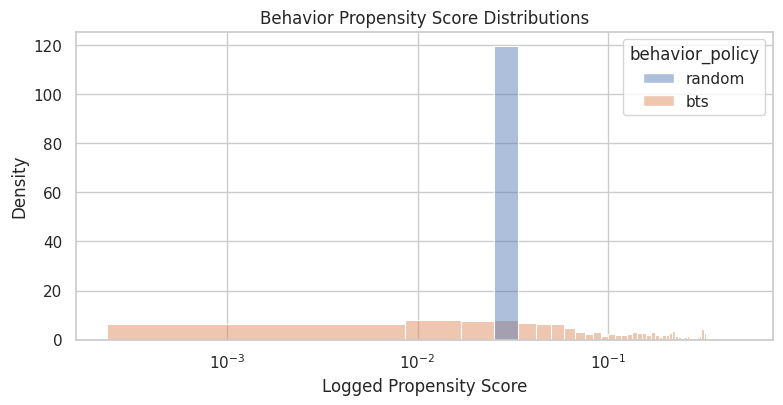

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=comparison_df,
    x="propensity_score",
    hue="behavior_policy",
    bins=60,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("Behavior Propensity Score Distributions")
ax.set_xlabel("Logged Propensity Score")
ax.set_ylabel("Density")
plt.show()


The propensity diagnostics show how much probability the behavior policy assigned to logged actions. Small propensities imply large inverse-propensity weights, which can make IPS estimates unstable.


## Random Policy Uniformity Check

For the `random/men` campaign, the behavior policy should be close to uniform over the available items. If there are `K` actions, the expected random propensity is approximately `1 / K`.

This cell compares the logged random propensities to that expected uniform value. We still use the logged propensities in OPE, but this check helps confirm that the random-policy slice behaves as advertised.


In [11]:
random_n_actions = random_df["item_id"].nunique()
random_expected_uniform_propensity = 1 / random_n_actions

random_uniformity = pd.Series(
    {
        "random_unique_items": random_n_actions,
        "expected_uniform_propensity": random_expected_uniform_propensity,
        "observed_min_propensity": random_df["propensity_score"].min(),
        "observed_max_propensity": random_df["propensity_score"].max(),
        "observed_mean_propensity": random_df["propensity_score"].mean(),
        "max_abs_difference_from_uniform": (random_df["propensity_score"] - random_expected_uniform_propensity).abs().max(),
    }
).to_frame("value")

random_uniformity


,value
random_unique_items,34.000000
expected_uniform_propensity,0.029412
observed_min_propensity,0.029412
observed_max_propensity,0.029412
observed_mean_propensity,0.029412
max_abs_difference_from_uniform,0.000000


The uniformity check tests whether the random logging policy behaves as expected. Random logs are especially valuable for OPE because they usually provide broader support than production-style adaptive policies.


## Action Distribution By Behavior Policy

This cell counts how often each item appears under each behavior policy. Broad action coverage is crucial because an evaluation policy can only be evaluated where the historical behavior policy collected useful data.

Random logging should be flatter. BTS should be more concentrated because it is learning which items seem promising and assigning them higher probability.


In [12]:
action_distribution = (
    comparison_df.groupby(["behavior_policy", "item_id"])
    .agg(
        rows=("click", "size"),
        click_rate=("click", "mean"),
        avg_propensity=("propensity_score", "mean"),
    )
    .reset_index()
)
action_distribution["row_share"] = action_distribution["rows"] / action_distribution.groupby("behavior_policy")[
    "rows"
].transform("sum")

action_distribution.sort_values(["behavior_policy", "rows"], ascending=[True, False]).head(20)


,behavior_policy,item_id,rows,click_rate,avg_propensity,row_share
13,bts,13,50055,0.007472,0.271668,0.250275
23,bts,23,29450,0.006961,0.155400,0.147250
9,bts,9,18410,0.006355,0.136031,0.092050
21,bts,21,12097,0.006283,0.080557,0.060485
3,bts,3,7635,0.005108,0.055114,0.038175
31,bts,31,7198,0.007502,0.047918,0.035990
27,bts,27,7158,0.004750,0.042910,0.035790
26,bts,26,6916,0.005350,0.039247,0.034580
0,bts,0,6236,0.003849,0.049725,0.031180
1,bts,1,5608,0.009807,0.040800,0.028040


The action distribution shows how often each item was logged. OPE relies on support: evaluation policies are only credible where the behavior policy logged enough comparable actions.


## Action Concentration Metrics

This cell summarizes how concentrated each behavior policy is across actions.

The Herfindahl index is the sum of squared action shares. It is higher when exposure is concentrated in fewer actions. The top-5 share tells us how much traffic goes to the five most common items. These metrics help explain why adaptive logging can be harder for OPE than random logging.


In [13]:
def normalized_entropy(shares):
    shares = np.asarray(shares, dtype=float)
    shares = shares[shares > 0]
    return -(shares * np.log(shares)).sum() / np.log(len(shares))

concentration_rows = []
for policy, policy_actions in action_distribution.groupby("behavior_policy"):
    shares = policy_actions["row_share"].to_numpy()
    concentration_rows.append(
        {
            "behavior_policy": policy,
            "unique_items": policy_actions["item_id"].nunique(),
            "min_rows_per_item": policy_actions["rows"].min(),
            "max_rows_per_item": policy_actions["rows"].max(),
            "max_item_share": policy_actions["row_share"].max(),
            "top_5_item_share": policy_actions.nlargest(5, "row_share")["row_share"].sum(),
            "herfindahl_index": np.square(shares).sum(),
            "normalized_entropy": normalized_entropy(shares),
        }
    )

concentration = pd.DataFrame(concentration_rows)
concentration


,behavior_policy,unique_items,min_rows_per_item,max_rows_per_item,max_item_share,top_5_item_share,herfindahl_index,normalized_entropy
0,bts,34,145,50055,0.250275,0.588235,0.107264,0.785435
1,random,34,5342,6473,0.032365,0.156720,0.029465,0.999743


The concentration metrics quantify how spread out the logging policy is across actions. Lower entropy or higher concentration means fewer actions dominate the log, increasing support risk.


## Plot Action Exposure Shares

This plot shows the action exposure profile under each behavior policy. The bars are sorted separately within each policy by exposure share.

A flatter random profile means it explores items evenly. A steeper BTS profile means some items receive much more traffic than others. That concentration can improve online reward for BTS, but it can make offline evaluation of very different policies more difficult.


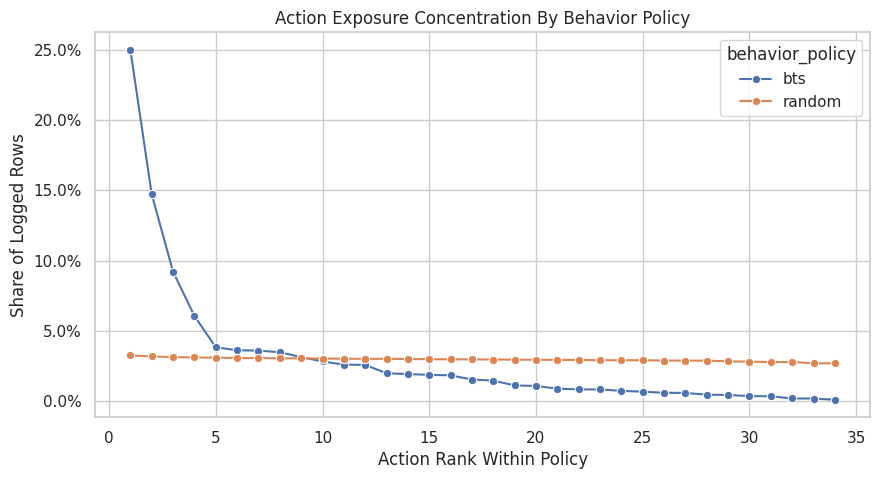

In [14]:
plot_action_distribution = (
    action_distribution.sort_values(["behavior_policy", "row_share"], ascending=[True, False])
    .assign(action_rank=lambda x: x.groupby("behavior_policy").cumcount() + 1)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=plot_action_distribution,
    x="action_rank",
    y="row_share",
    hue="behavior_policy",
    marker="o",
    ax=ax,
)
ax.set_title("Action Exposure Concentration By Behavior Policy")
ax.set_xlabel("Action Rank Within Policy")
ax.set_ylabel("Share of Logged Rows")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
plt.show()


The action exposure plot reveals whether the logging policy spreads probability broadly or concentrates on a few items. Concentration creates support risk for policies that choose rarely logged actions.


## Position Distribution By Behavior Policy

Open Bandit logs the position where the item was shown. Position is not the main action in this project, but it affects click probability and can interact with item choice.

This cell checks whether the two behavior policies use the three positions similarly. If one policy used certain positions much more often, reward comparisons would need to account for that context difference.


In [15]:
position_distribution = (
    comparison_df.groupby(["behavior_policy", "position"])
    .agg(
        rows=("click", "size"),
        click_rate=("click", "mean"),
        avg_propensity=("propensity_score", "mean"),
    )
    .reset_index()
)
position_distribution["row_share"] = position_distribution["rows"] / position_distribution.groupby("behavior_policy")[
    "rows"
].transform("sum")

position_distribution


,behavior_policy,position,rows,click_rate,avg_propensity,row_share
0,bts,1,66643,0.006467,0.140928,0.333215
1,bts,2,66674,0.006614,0.134425,0.333370
2,bts,3,66683,0.005009,0.099227,0.333415
3,random,1,66653,0.005746,0.029412,0.333265
4,random,2,66679,0.005114,0.029412,0.333395
5,random,3,66668,0.004710,0.029412,0.333340


The position summary checks where logged recommendations appeared in the slate. Position can affect reward, so understanding its distribution helps interpret later policy-value comparisons.


## Plot Position Click Rates

This plot compares click rates by position across the two behavior policies. Position-level CTR differences should be treated descriptively here.

A higher click rate under BTS does not automatically mean BTS is causally better in this sample. BTS may choose different items, with different propensities, for different contexts. The point is to understand the logged data before using causal estimators.


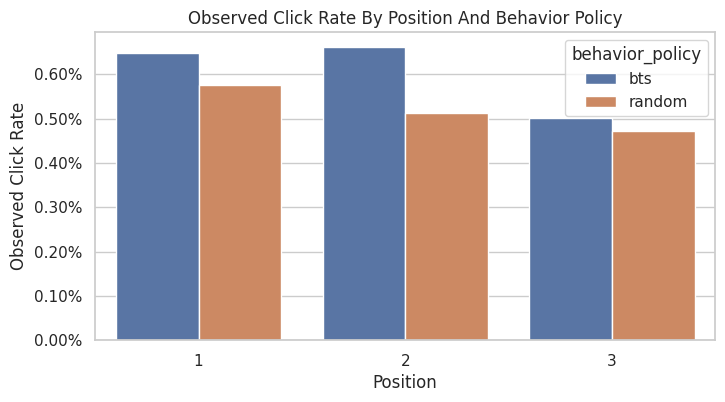

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=position_distribution, x="position", y="click_rate", hue="behavior_policy", ax=ax)
ax.set_title("Observed Click Rate By Position And Behavior Policy")
ax.set_xlabel("Position")
ax.set_ylabel("Observed Click Rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.show()


The position CTR plot shows whether click rates vary by slate position. This is a useful reminder that logged reward is shaped by presentation context, not only by the item identity.


## Action-Position Support Matrix

An evaluation policy might choose different items in different positions. That means we should check not only whether each item appears, but also whether each item-position pair appears.

This cell builds action-position count matrices for each behavior policy. Missing or very small cells are warning signs for policies that rely heavily on those action-position combinations.


In [17]:
random_action_position = random_df.pivot_table(
    index="item_id", columns="position", values="click", aggfunc="size", fill_value=0
).astype(int)
bts_action_position = bts_df.pivot_table(
    index="item_id", columns="position", values="click", aggfunc="size", fill_value=0
).astype(int)

support_summary = pd.DataFrame(
    [
        {
            "behavior_policy": "random",
            "observed_action_position_cells": int((random_action_position > 0).sum().sum()),
            "total_action_position_cells": int(random_action_position.size),
            "min_nonzero_cell_count": int(random_action_position[random_action_position > 0].min().min()),
            "zero_cells": int((random_action_position == 0).sum().sum()),
        },
        {
            "behavior_policy": "bts",
            "observed_action_position_cells": int((bts_action_position > 0).sum().sum()),
            "total_action_position_cells": int(bts_action_position.size),
            "min_nonzero_cell_count": int(bts_action_position[bts_action_position > 0].min().min()),
            "zero_cells": int((bts_action_position == 0).sum().sum()),
        },
    ]
)

support_summary


,behavior_policy,observed_action_position_cells,total_action_position_cells,min_nonzero_cell_count,zero_cells
0,random,102,102,1634,0
1,bts,102,102,35,0


The action-position support table shows whether items are observed across the presentation contexts where evaluation policies might place them. Sparse cells warn that value estimates may rely on extrapolation or heavy weights.


## Plot Action-Position Support

These heatmaps show logged counts for each item-position pair. The color scale uses `log1p(count)` so both small and large counts are visible.

The random policy should show broad, even support. BTS may show uneven support because it adaptively allocates more exposure to some item-position pairs.


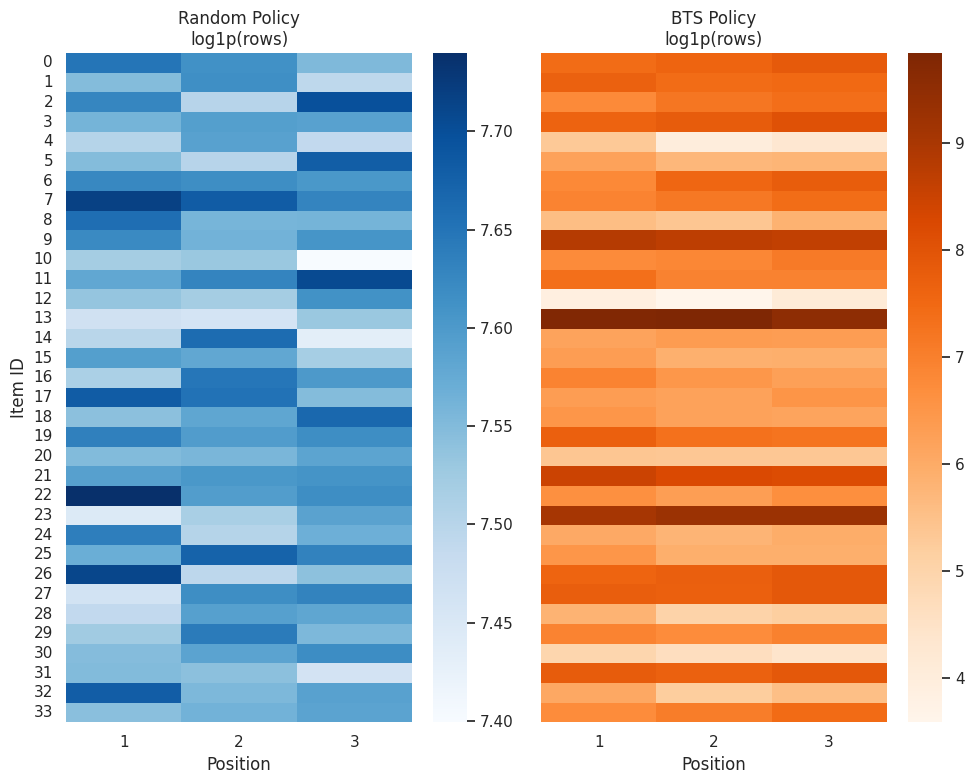

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

sns.heatmap(np.log1p(random_action_position), cmap="Blues", cbar=True, ax=axes[0])
axes[0].set_title("Random Policy\nlog1p(rows)")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Item ID")

sns.heatmap(np.log1p(bts_action_position), cmap="Oranges", cbar=True, ax=axes[1])
axes[1].set_title("BTS Policy\nlog1p(rows)")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


The action-position support table shows whether items are observed across the presentation contexts where evaluation policies might place them. Sparse cells warn that value estimates may rely on extrapolation or heavy weights.


## Inverse Behavior Propensity Diagnostics

Inverse behavior propensity, `1 / propensity_score`, is not yet an OPE weight because we have not defined an evaluation policy. However, it is a useful upper-risk diagnostic.

When behavior propensities are small, inverse propensities are large. Large weights can make IPS estimates noisy because a few rows can dominate the average.


In [19]:
inverse_propensity_percentiles = (
    comparison_df.groupby("behavior_policy")["inverse_behavior_propensity"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])
    .reset_index()
)

inverse_propensity_percentiles


,behavior_policy,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
0,bts,200000.000000,32.824107,90.424960,1.993203,2.272986,3.131115,3.273537,11.588157,69.036935,118.203310,344.234079,4255.319149
1,random,200000.000000,34.000000,0.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000


This output is part of the behavior-policy propensities and support diagnostics workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


## Plot Inverse Propensity Distributions

This plot shows how large `1 / propensity_score` can become under each behavior policy. The x-axis uses a log scale because inverse propensities can vary substantially under adaptive logging.

For OPE, this is the variance warning light. A long right tail means later IPS estimates may be sensitive to a small number of logged events.


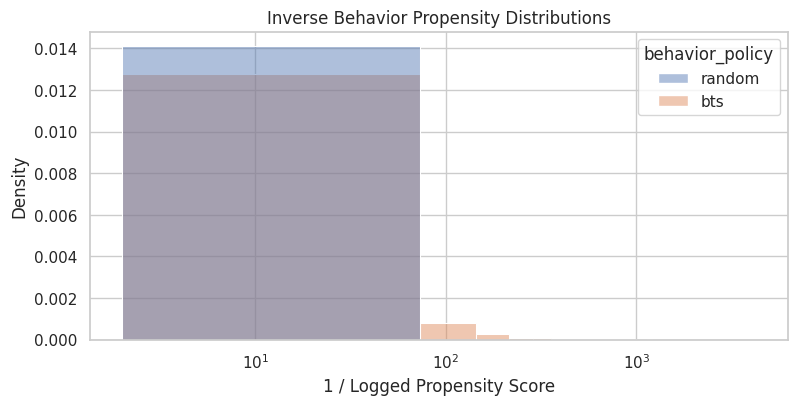

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=comparison_df,
    x="inverse_behavior_propensity",
    hue="behavior_policy",
    bins=60,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("Inverse Behavior Propensity Distributions")
ax.set_xlabel("1 / Logged Propensity Score")
ax.set_ylabel("Density")
plt.show()


The propensity diagnostics show how much probability the behavior policy assigned to logged actions. Small propensities imply large inverse-propensity weights, which can make IPS estimates unstable.


## Effective Sample Size For Candidate Weights

Effective sample size, or ESS, summarizes weight concentration:

`ESS = (sum weights)^2 / sum(weights^2)`

If all weights are equal, ESS equals the number of rows. If a few rows have huge weights, ESS becomes much smaller. This cell computes ESS for inverse behavior propensities as a generic risk diagnostic.


In [21]:
ess_rows = []
for policy, policy_df in comparison_df.groupby("behavior_policy"):
    weights = policy_df["inverse_behavior_propensity"].to_numpy()
    ess = effective_sample_size(weights)
    ess_rows.append(
        {
            "behavior_policy": policy,
            "rows": len(policy_df),
            "inverse_propensity_ess": ess,
            "ess_share_of_rows": ess / len(policy_df),
            "max_inverse_propensity": weights.max(),
            "p99_inverse_propensity": np.percentile(weights, 99),
        }
    )

inverse_ess = pd.DataFrame(ess_rows)
inverse_ess


,behavior_policy,rows,inverse_propensity_ess,ess_share_of_rows,max_inverse_propensity,p99_inverse_propensity
0,bts,200000,23285.403834,0.116427,4255.319149,344.234079
1,random,200000,200000.000000,1.000000,34.000000,34.000000


Effective sample size turns weight concentration into an intuitive sample-size diagnostic. A low ESS means the estimator has less usable information than the raw row count suggests.


## Uniform Evaluation Policy Weight Preview

This cell previews a real OPE weight for a simple evaluation policy: a uniform policy over the observed action set.

For random logging, this evaluation policy is nearly identical to the behavior policy, so weights should be close to 1. For BTS logging, the same uniform evaluation policy can create more variable weights because BTS does not choose all actions uniformly.

This is still a diagnostic preview. The next notebook will define evaluation policies more formally and estimate IPS/SNIPS policy values.


In [22]:
uniform_weight_frames = []
for policy, policy_df in comparison_df.groupby("behavior_policy"):
    n_actions = policy_df["item_id"].nunique()
    uniform_eval_prob = 1 / n_actions
    weights = uniform_eval_prob / policy_df["propensity_score"]
    uniform_weight_frames.append(
        policy_df[["behavior_policy", "item_id", "position", "click", "propensity_score"]].assign(
            uniform_eval_prob=uniform_eval_prob,
            uniform_policy_weight=weights,
        )
    )

uniform_weight_df = pd.concat(uniform_weight_frames, ignore_index=True)

uniform_weight_summary = (
    uniform_weight_df.groupby("behavior_policy")["uniform_policy_weight"]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
    .reset_index()
)
uniform_weight_summary["ess"] = uniform_weight_df.groupby("behavior_policy")["uniform_policy_weight"].apply(
    effective_sample_size
).values
uniform_weight_summary["ess_share_of_rows"] = uniform_weight_summary["ess"] / uniform_weight_summary["count"]

uniform_weight_summary


,behavior_policy,count,mean,std,min,1%,5%,50%,95%,99%,max,ess,ess_share_of_rows
0,bts,200000.000000,0.965415,2.659558,0.058624,0.066853,0.092092,0.340828,3.476568,10.124532,125.156446,23285.403834,0.116427
1,random,200000.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,200000.000000,1.000000


The uniform-policy weight preview shows what OPE weights would look like for a simple benchmark policy. This is a low-complexity way to build intuition before evaluating more targeted policies.


## Plot Uniform Policy Weights

This plot visualizes the candidate weights for evaluating a uniform policy from each behavior log.

The random-policy weights should be tightly centered near 1. The BTS weights should be more dispersed. This is a concrete example of why the same evaluation policy can be easy to estimate from randomized logs and harder to estimate from adaptive logs.


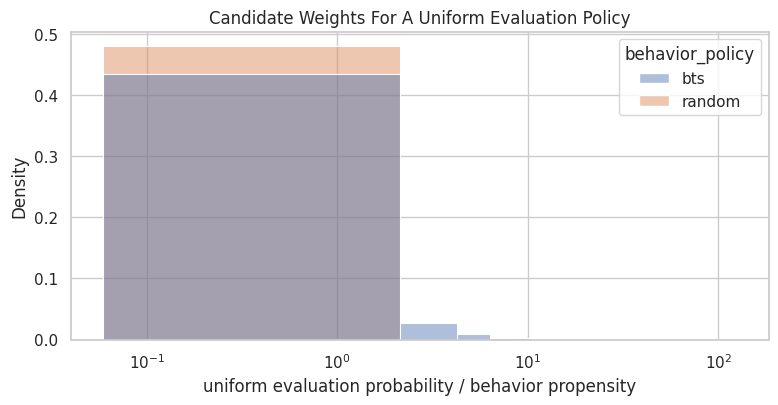

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=uniform_weight_df,
    x="uniform_policy_weight",
    hue="behavior_policy",
    bins=60,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("Candidate Weights For A Uniform Evaluation Policy")
ax.set_xlabel("uniform evaluation probability / behavior propensity")
ax.set_ylabel("Density")
plt.show()


The uniform-policy weight preview shows what OPE weights would look like for a simple benchmark policy. This is a low-complexity way to build intuition before evaluating more targeted policies.


## Naive Observed Click Rate Comparison

This cell compares raw observed click rates under random and BTS logging. This is intentionally labeled naive.

A raw click-rate comparison is not an off-policy estimate because the two behavior policies choose different item distributions. BTS may look better because it learned to favor better items, because it served different contexts, or because of both. Proper policy evaluation requires reweighting or modeling.


In [24]:
naive_policy_values = (
    comparison_df.groupby("behavior_policy")
    .agg(rows=("click", "size"), observed_click_rate=("click", "mean"))
    .reset_index()
)
naive_policy_values["standard_error"] = comparison_df.groupby("behavior_policy")["click"].apply(
    lambda x: x.std(ddof=1) / np.sqrt(len(x))
).values

naive_policy_values


,behavior_policy,rows,observed_click_rate,standard_error
0,bts,200000,0.006030,0.000173
1,random,200000,0.005190,0.000161


The observed behavior-policy value is the logged baseline. It is not the value of a new policy, but it gives a reference point for whether evaluated policies appear better or worse offline.


## Plot Naive Observed Click Rates

This plot is useful because it shows why adaptive policies are tempting: they may have higher observed reward in the logs.

But the notebook should not stop at this plot. The causal question is not simply which log has higher click rate. The causal question is how a target evaluation policy would perform under the same population and context distribution.


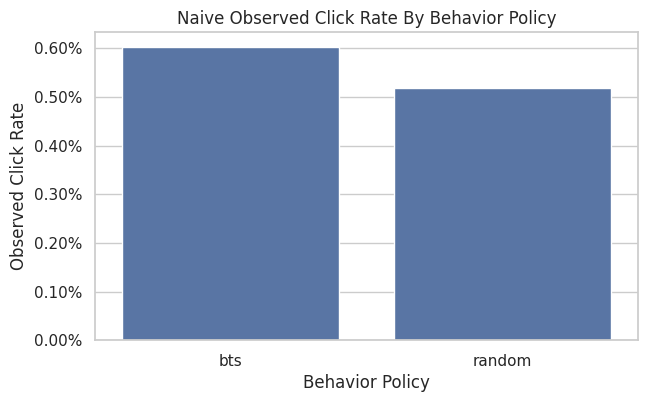

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=naive_policy_values, x="behavior_policy", y="observed_click_rate", ax=ax)
ax.set_title("Naive Observed Click Rate By Behavior Policy")
ax.set_xlabel("Behavior Policy")
ax.set_ylabel("Observed Click Rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.show()


The observed behavior-policy value is the logged baseline. It is not the value of a new policy, but it gives a reference point for whether evaluated policies appear better or worse offline.


## Support Risk By Action

This cell identifies actions with the least support under each behavior policy. These actions are where an evaluation policy would be hardest to evaluate precisely.

For example, if a future policy heavily recommends an item that BTS rarely selected, BTS logs may yield high-variance estimates for that policy. Random logs are less likely to have this issue because exposure is more even.


In [26]:
least_supported_actions = (
    action_distribution.sort_values(["behavior_policy", "rows"], ascending=[True, True])
    .groupby("behavior_policy")
    .head(8)
    .reset_index(drop=True)
)

least_supported_actions


,behavior_policy,item_id,rows,click_rate,avg_propensity,row_share
0,bts,12,145,0.000000,0.004161,0.000725
1,bts,30,321,0.000000,0.003403,0.001605
2,bts,4,327,0.000000,0.004933,0.001635
3,bts,20,638,0.000000,0.005284,0.003190
4,bts,28,665,0.000000,0.004773,0.003325
5,bts,8,829,0.001206,0.011478,0.004145
6,bts,32,865,0.005780,0.010043,0.004325
7,bts,5,1118,0.008945,0.009086,0.005590
8,random,10,5342,0.005241,0.029412,0.026710
9,random,13,5348,0.007105,0.029412,0.026740


The support-risk output identifies actions or rows that are poorly covered by the behavior policy. These are the cases most likely to create unstable weights or unreliable counterfactual estimates.


## Support Risk By Propensity

Action counts are useful, but propensity scores are even more directly tied to OPE. This cell identifies rows with the smallest logged propensities under each behavior policy.

Small propensities do not automatically invalidate OPE, but they warn us that estimators may need clipping, self-normalization, doubly robust modeling, or careful evaluation-policy design.


In [27]:
smallest_propensity_rows = (
    comparison_df.sort_values(["behavior_policy", "propensity_score"], ascending=[True, True])
    .groupby("behavior_policy")
    .head(10)
    .reset_index(drop=True)
)

smallest_propensity_rows[["behavior_policy", "timestamp", "item_id", "position", "click", "propensity_score", "inverse_behavior_propensity"]]


,behavior_policy,timestamp,item_id,position,click,propensity_score,inverse_behavior_propensity
0,bts,2019-11-24 03:59:00.913324+00:00,12,2,0,0.000235,4255.319149
1,bts,2019-11-24 03:59:01.983928+00:00,12,2,0,0.000235,4255.319149
2,bts,2019-11-24 03:59:02.199113+00:00,12,2,0,0.000235,4255.319149
3,bts,2019-11-24 03:59:05.032877+00:00,12,2,0,0.000235,4255.319149
4,bts,2019-11-24 03:59:06.902389+00:00,12,2,0,0.000235,4255.319149
5,bts,2019-11-24 03:59:07.450618+00:00,12,2,0,0.000235,4255.319149
6,bts,2019-11-24 03:59:08.711859+00:00,12,2,0,0.000235,4255.319149
7,bts,2019-11-24 03:59:12.348441+00:00,12,2,0,0.000235,4255.319149
8,bts,2019-11-24 02:07:08.701458+00:00,12,3,0,0.000300,3333.333333
9,bts,2019-11-24 02:07:09.225994+00:00,12,3,0,0.000300,3333.333333


The support-risk output identifies actions or rows that are poorly covered by the behavior policy. These are the cases most likely to create unstable weights or unreliable counterfactual estimates.


## OPE Readiness Checklist

This cell converts the diagnostics into a compact checklist for the next notebook. It distinguishes between basic feasibility and estimator stability.

The main takeaway should be: both policies contain valid propensities, but random logging is cleaner for first-pass OPE because support is broader and weights are more stable.


In [28]:
readiness_checks = pd.DataFrame(
    [
        {
            "check": "Random propensities are positive",
            "status": bool((random_df["propensity_score"] > 0).all()),
            "why_it_matters": "Required for IPS on logged random-policy rows.",
        },
        {
            "check": "BTS propensities are positive",
            "status": bool((bts_df["propensity_score"] > 0).all()),
            "why_it_matters": "Required for IPS on logged BTS-policy rows.",
        },
        {
            "check": "Random action support is broad",
            "status": concentration.loc[concentration["behavior_policy"] == "random", "min_rows_per_item"].iloc[0] > 100,
            "why_it_matters": "Each item has many observations in the sample.",
        },
        {
            "check": "Random weights are stable for uniform policy",
            "status": uniform_weight_summary.loc[
                uniform_weight_summary["behavior_policy"] == "random", "ess_share_of_rows"
            ].iloc[0] > 0.95,
            "why_it_matters": "Uniform evaluation from random logs should be low variance.",
        },
        {
            "check": "BTS requires more careful weighting",
            "status": uniform_weight_summary.loc[
                uniform_weight_summary["behavior_policy"] == "bts", "ess_share_of_rows"
            ].iloc[0] < 0.95,
            "why_it_matters": "Adaptive logging creates more variable weights.",
        },
    ]
)

readiness_checks


,check,status,why_it_matters
0,Random propensities are positive,True,Required for IPS on logged random-policy rows.
1,BTS propensities are positive,True,Required for IPS on logged BTS-policy rows.
2,Random action support is broad,True,Each item has many observations in the sample.
3,Random weights are stable for uniform policy,True,Uniform evaluation from random logs should be ...
4,BTS requires more careful weighting,True,Adaptive logging creates more variable weights.


The readiness checklist summarizes whether the log has the essentials for OPE: rewards, actions, propensities, support, and enough sample size. Passing these checks justifies moving from EDA to estimator design.


## Cache The BTS Sample

This cell saves the parsed BTS sample to parquet. The next notebooks can use this cache for quick diagnostics or comparisons without repeatedly scanning the large zip file.

The raw zip remains the source of truth. This parquet file is a local convenience artifact for faster iteration.


In [29]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
bts_df.to_parquet(BTS_SAMPLE_PATH, index=False)

BTS_SAMPLE_PATH


PosixPath('/home/apex/Documents/ranking_sys/data/processed/open_bandit_bts_men_sample.parquet')

This cell saves reusable outputs for downstream notebooks or the final writeup. Persisting these artifacts makes the project modular and prevents later notebooks from repeating expensive or fragile setup work.


## Notebook 2 Takeaways

The Open Bandit logs pass the basic feasibility checks for off-policy evaluation: actions, rewards, and positive propensities are present.

The `random/men` sample is the best starting point for the first OPE estimators because its action support is broad and its propensities are nearly uniform. That makes simple IPS and SNIPS easier to explain and less sensitive to extreme weights.

The `bts/men` sample is valuable as a comparison because it shows the realistic complication introduced by adaptive logging. BTS concentrates more traffic on some actions and produces more variable propensities. That does not make BTS unusable, but it means later estimates need stronger diagnostics, possible weight clipping, and doubly robust modeling.

Notebook 3 should now define one or two simple evaluation policies and estimate their values with IPS and self-normalized IPS.
